In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np 
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
import cv2
import os
import matplotlib.pyplot as plt
import torch.optim as optim
from darts_dataset import SyntheticDataset, RealWorldDataset
from darts_model import CNNTransformer, DomainDiscriminator, loss_corners, loss_darts, loss_labels, match
from score import get_score, fields

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
BATCH_SIZE=25
BATCH_SIZE_UNLABELED=15
DATA_DIRECTORY = "./3D"
LABELS_FILENAME = "labels_14.pkl"
LABELS_FILEPATH =f"{DATA_DIRECTORY}/{LABELS_FILENAME}"

In [5]:
df=pd.read_pickle(LABELS_FILEPATH)
# df = df[:-7]
# df[df["img_folder"] == "C:/Users/Tim/Documents/dev/playdarts/3D/imgs_0002"] = df[df["img_folder"] == "C:/Users/Tim/Documents/dev/playdarts/3D/imgs_0002"][7:]
# df = df.dropna(subset=['img_folder'])
df.head()

,img_folder,img_name,xy
0,C:/Users/Tim/Documents/dev/playdarts/3D/imgs_0000,img_0000.png,"[[0.4470035135746002, 0.16692721843719482], [0..."
1,C:/Users/Tim/Documents/dev/playdarts/3D/imgs_0000,img_0001.png,"[[0.4893050789833069, 0.2718982696533203], [0...."
2,C:/Users/Tim/Documents/dev/playdarts/3D/imgs_0000,img_0002.png,"[[0.4684809744358063, 0.25501418113708496], [0..."
3,C:/Users/Tim/Documents/dev/playdarts/3D/imgs_0000,img_0003.png,"[[0.4767518639564514, 0.3311116695404053], [0...."
4,C:/Users/Tim/Documents/dev/playdarts/3D/imgs_0000,img_0004.png,"[[0.46220868825912476, 0.25976938009262085], [..."


In [6]:
# df.to_pickle("./3D/labels.pkl")

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),          # Convert to tensor (scales pixel values to [0,1])
    transforms.Resize(512),  # ResNet-50 expects 224x224 images
    transforms.CenterCrop(512),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean
                         std=[0.229, 0.224, 0.225])   # ImageNet std
])

In [8]:
dataset = SyntheticDataset("./3D", LABELS_FILEPATH, transform=transform)
target_dataset = RealWorldDataset("./unlabeled/train/", "./unlabeled/train/_annotations.csv", transform=transform)
dataloader = DataLoader(dataset, collate_fn=SyntheticDataset.collate_fn, batch_size=BATCH_SIZE, shuffle=True, num_workers=1, persistent_workers=True, drop_last=True)
target_dataloader = DataLoader(target_dataset, batch_size=BATCH_SIZE_UNLABELED, shuffle=True, num_workers=1, persistent_workers=True, drop_last=True)

                                          img_folder      img_name  \
0  C:/Users/Tim/Documents/dev/playdarts/3D/imgs_0000  img_0000.png   
1  C:/Users/Tim/Documents/dev/playdarts/3D/imgs_0000  img_0001.png   
2  C:/Users/Tim/Documents/dev/playdarts/3D/imgs_0000  img_0002.png   
3  C:/Users/Tim/Documents/dev/playdarts/3D/imgs_0000  img_0003.png   
4  C:/Users/Tim/Documents/dev/playdarts/3D/imgs_0000  img_0004.png   

                                                  xy  
0  [[0.4470035135746002, 0.16692721843719482], [0...  
1  [[0.4893050789833069, 0.2718982696533203], [0....  
2  [[0.4684809744358063, 0.25501418113708496], [0...  
3  [[0.4767518639564514, 0.3311116695404053], [0....  
4  [[0.46220868825912476, 0.25976938009262085], [...  


c:\Users\Tim\Documents\dev\playdarts\darts_dataset.py:45: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  xy = torch.tensor(self.labels.iloc[idx]['xy'], dtype=torch.float32)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(array([16]), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([[ 8.61754009, -1.29659338, -3.60692934],
       [-0.80749948, -8.33524769,  4.58945461],
       [-0.63260272,  0.41451531,  1.        ]]))


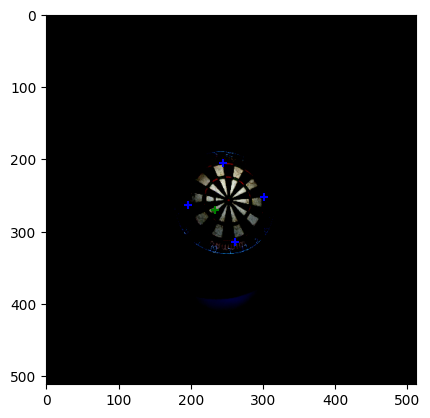

In [9]:
image, target = dataset[np.random.randint(len(dataset))]
_, w, h = image.shape
print(get_score(target["corners"], target["darts"]))
fig, ax = plt.subplots(1)
ax.imshow(image.cpu().permute(1,2,0))
ax.scatter(target["corners"][:, 0]*w, target["corners"][:, 1]*h, color='blue', s=40, marker='+', label="corners")
ax.scatter(target["darts"][:, 0]*w, target["darts"][:, 1]*h, color='green', s=40, marker='+', label="darts")

In [10]:
query_dim = 256
model = CNNTransformer(d=query_dim).to(device)
discriminator = DomainDiscriminator(query_dim, 512, 2).to(device)

C:\Users\Tim\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Tim\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\Tim\AppData\Roaming\Python\Python312\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [11]:
param_dicts = [
    {"params": [p for n, p in model.named_parameters() if "backbone" not in n and p.requires_grad]},
    {
        "params": [p for n, p in model.named_parameters() if "backbone" in n and p.requires_grad],
        "lr": 1e-5,
    },
    {
        "params": [p for p in discriminator.parameters() if p.requires_grad],
    }
]

In [12]:
# model.transformer.apply(initialize_weights)
optimizer = optim.AdamW(param_dicts, lr=1e-4, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 200)

In [13]:
# model.load_state_dict(torch.load("models/epoch_300_0.0108_0.0213_0.0059_0.7449.pt", weights_only=True))

In [14]:
NUM_EPOCHS=100

In [ ]:
model.train()  # Set model to training mode
mse_loss = nn.MSELoss()

for epoch in range(NUM_EPOCHS):
    total_loss = 0
    total_corner_loss = 0
    total_darts_loss = 0
    total_label_loss = 0
    total_domain_acc = 0
    
    source_iter, target_iter = iter(dataloader), iter(target_dataloader)
    num_batches = min(len(source_iter), len(target_iter))
    for batch in range(num_batches):
        images, targets = next(source_iter)
        target_images = next(target_iter).to(device)
        images = images.to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        all_images = torch.cat((images, target_images))
        domain_labels = torch.cat((
            torch.zeros(BATCH_SIZE, dtype=torch.long, device=device),
            torch.ones(BATCH_SIZE_UNLABELED, dtype=torch.long, device=device)
        ))
        bs, channels, w, h = images.shape
        optimizer.zero_grad()          
        outputs = model(all_images)
        
        outputs["corners"] = outputs["corners"][:BATCH_SIZE]
        outputs["darts"] = outputs["darts"][:BATCH_SIZE]
        outputs["is_dart"] = outputs["is_dart"][:BATCH_SIZE]
        outputs["is_dart_logits"] = outputs["is_dart_logits"][:BATCH_SIZE]
        indices = match(outputs, targets)
        lc = loss_corners(outputs, targets)
        ld = loss_darts(outputs, targets, indices)
        ll = loss_labels(outputs, indices)
        # loss_distance = -torch.cdist(outputs["corners"], outputs["corners"], p=1).mean()
        pred_domain = discriminator(outputs["extracted_features"])
        ldomain = nn.functional.cross_entropy(pred_domain, domain_labels, weight=torch.as_tensor([(BATCH_SIZE+BATCH_SIZE_UNLABELED)/BATCH_SIZE, (BATCH_SIZE+BATCH_SIZE_UNLABELED)/BATCH_SIZE_UNLABELED], device=device))
        loss = 15*lc + 15*ld + 3*ll + 1*ldomain
        # if epoch < 3:
        #     loss += loss_distance
        loss.backward()                # Backpropagation
        optimizer.step()               # Update weights
        total_loss += loss.item()
        total_corner_loss += lc.item()
        total_darts_loss += ld.item()
        total_label_loss += ll.item()
        total_domain_acc += torch.mean((pred_domain.argmax(dim=-1) == domain_labels).float()).item()
        if (batch+1) % 20 == 0:
            print(lc.item(), ld.item(), ll.item(), ldomain.item())
    lr_scheduler.step()
    if (epoch+1) % 10 == 0:
        print("saving model...")
        torch.save(model.state_dict(), f"models/epoch_{epoch+1}_{total_corner_loss/num_batches:.4f}_{total_darts_loss/num_batches:.4f}_{total_label_loss/num_batches:.4f}_{total_domain_acc/num_batches:.4f}.pt")
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Losses: {total_corner_loss/num_batches:.4f}, {total_darts_loss/num_batches:.4f}, {total_label_loss/num_batches:.4f}, {total_domain_acc/num_batches:.4f}", )

0.16901902854442596 0.09274155646562576 0.6367058157920837 0.02139357291162014
0.15508556365966797 0.10800016671419144 0.6875543594360352 0.001685114810243249
0.14762963354587555 0.07239942252635956 0.6788923740386963 0.0005436772480607033
0.15297192335128784 0.06231428682804108 0.6591544151306152 0.0003958560118917376
0.1332874596118927 0.06359311938285828 0.6615672707557678 0.0007184941205196083
0.08873554319143295 0.11717527359724045 0.8265393376350403 0.00017672410467639565
0.04668354243040085 0.07379503548145294 0.6745914220809937 0.001178661361336708
Epoch [1/100], Losses: 0.1289, 0.0892, 0.6869, 0.9876
0.04906579852104187 0.07103656977415085 0.6575631499290466 0.0008060806430876255
0.04364055022597313 0.08477931469678879 0.6326420307159424 0.046382203698158264
0.056184619665145874 0.08809507638216019 0.6517290472984314 0.010918879881501198
0.041337598115205765 0.09218575060367584 0.4850946068763733 0.1068166196346283
0.03488659858703613 0.07918812334537506 0.6073604822158813 0.0

KeyboardInterrupt: 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


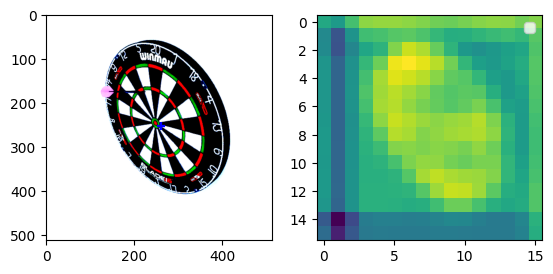

In [ ]:
model.eval()
idx = np.random.randint(len(dataset))
image, targets = dataset[idx]
images = image.unsqueeze(0).to(device)
targets = [targets]
batch_size, channels, w, h = images.shape
optimizer.zero_grad()          
outputs = model(images)
pred_classes = torch.argmax(outputs["is_dart"], dim=-1)
print()
fig, ax = plt.subplots(1, 2)
ax[0].imshow(images[0].cpu().permute(1,2,0))
ax[1].imshow(outputs["extracted_features"][0].mean(dim=0).cpu().detach())


pred_corners = outputs["corners"][0].cpu().detach()
pred_darts = outputs["darts"][0][outputs["is_dart"][0, :, 1] > outputs["is_dart"][0, :, 0]].cpu().detach()
all_darts = outputs["darts"][0].cpu().detach()

# Draw points
ax[0].scatter(pred_corners[:, 0]*w, pred_corners[:, 1]*h, color='blue', s=40, marker='+', label="pred corners")
ax[0].scatter(all_darts[:, 0]*w, all_darts[:, 1]*h, color='white', s=10, marker='x', label="all darts")
ax[0].scatter(pred_darts[:, 0]*w, pred_darts[:, 1]*h, color='red', s=40, marker='+', label="pred darts")
ax[0].scatter(targets[0]["corners"][:, 0]*w, targets[0]["corners"][:, 1]*h, color='blue', s=10, marker='o', label="gt corners")
ax[0].scatter(targets[0]["darts"][:, 0]*w, targets[0]["darts"][:, 1]*h, color='red', s=10, marker='o', label="gt darts")

# Show plot
plt.legend()
plt.show()